# Alignment of the cerebellar

Align the cerebellar voxels better for use in regression - to look at changes only in the cerebellum.

Make sure that all names are for new files, not overwriting any present files (all in smarts_cerebellum directory)

In [1]:
# Imports

# model libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# image reading libraries
import nibabel as nib
from nilearn import plotting as npl
from nilearn import masking # for masking within-brain voxels

import nitools as nt

from pathlib import Path
import os

In [2]:
# directories
base_dir = '/cifs/diedrichsen/data/smarts_cerebellum'
anat_dir = '/cifs/diedrichsen/data/smarts_cerebellum/anatomicals'
p_df = pd.read_csv('/cifs/diedrichsen/data/smarts_cerebellum/participants_anat.tsv', sep = '\t')

In [3]:
# 1. get the cerebellar isolation mask (SUITPy pipeline) and the T1 anatomical

In [ ]:
# 2. get the cerebellar image: multiply mask (binary) by the T1 anat

# note: do we need world coordinates here? Probably best to do it with voxel-space, since we are after the affine, and the affine from this image is from previous coregistration

# save image as _T1_cerebellum_only.nii

# NOT .nii.gz - SPM does NOT take .gz

In [5]:
# 3. SPM coregistration - save this to a new file!

In [ ]:
# 4. assign affine from coregistered cerebellar image to the T1 anatomical for that subject (overwrites the present affine from previous coregistration)

# save as a new image

In [7]:
# 5. also assign above affine to the white matter probability map - use the affine from image generated from 4

## Trying all these steps on one sample subject first

On CU_2538 since they had the cerebral swelling, so slope issue (from coregistration alignment issue) in cerebrum (image shfit shown).

In [3]:
# trying this on sample subject
subj_id = 'CU_2538'
refT1 = 'W0'

In [52]:
# working on one week at a time for now...also we chose CU_2538, who only has two measurement weeks.
# started with W4, now do W0
week = 'W4'

note that we are first doing this on the later week's image; we also need to do this for the reference image to have a cerebellum-only reference (this is kinda the entire point of this exercise)

In [ ]:
week_T1_path = f'{anat_dir}/{subj_id}/{week}/{subj_id}_{week}_T1.nii'
week_mask_path = f'{anat_dir}/{subj_id}/{week}/iso_norm/{subj_id}_{week}_T1_cerebellum_dseg.nii'

In [54]:
week_T1_img = nib.load(week_T1_path)
week_mask_img = nib.load(week_mask_path)

In [55]:
# multiply mask (binary) by T1 anatomical to get cerebellum-only image
week_T1_arr = week_T1_img.get_fdata()
week_mask_arr = week_mask_img.get_fdata()

In [56]:
# in what order should we multiply these tensors? Figure it out.
week_cerebel_arr = week_T1_arr*week_mask_arr

Ask: to save the cerebellum image, which affine should I use?
- the same as the T1 anat, or from the isolation mask? They have the same affine (as expected...), so is this affine fine to use?
- this means that the affine presently being used is from previous coregistration - does this matter, since we're re-coregistering (so affine overwritten)?

In [57]:
# write back to nifti; use same affine as the t1 anat for now?
week_cerebel_img = nib.Nifti1Image(week_cerebel_arr, week_mask_img.affine)

# check: voxel size, affine (compared to T1 anat, isolation mask)

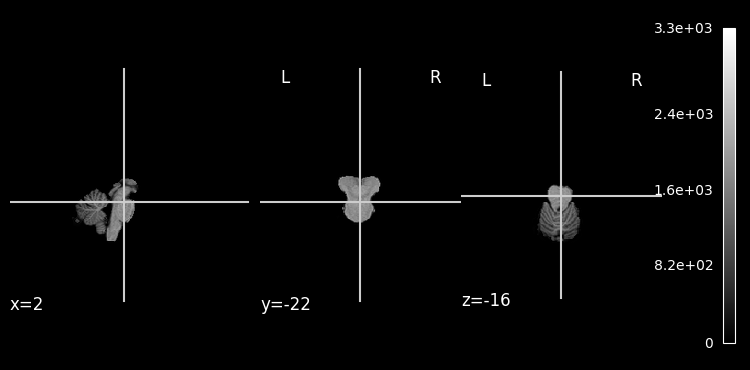

In [58]:
npl.plot_anat(week_cerebel_img)

# fix suffix:
T1_cerebellum_only.nii.gz

In [ ]:
nib.save(week_cerebel_img, f'{subj_id}_{week}_cerebellum_only_trial.nii.gz')


Ran SPM coregistration. File in .nii extension (SPM not take .nii.gz)

Now, assign affine from this cerebellar transform to the T1 anat corresponding to it - save it as a new file (so that we can compare) (and save all others as a new file, too!)

In [81]:
subj_id = 'CU_2538'
refT1 = 'W0'
week = 'W4'

In [73]:
cerebel_ref_path = f'{anat_dir}/{subj_id}/{refT1}/{subj_id}_{refT1}_cerebellum_only_trial.nii'

In [82]:
cerebel_week_path = f'{anat_dir}/{subj_id}/{week}/{subj_id}_{week}_cerebellum_only_trial.nii'

In [83]:
cerebel_ref_img = nib.load(cerebel_ref_path)
cerebel_week_img = nib.load(cerebel_week_path)

In [88]:
# assign affine from cerebellar image to its corresponding t1 anat
t1_week_path = f'{anat_dir}/{subj_id}/{week}/{subj_id}_{week}_T1.nii'
t1_week_img = nib.load(t1_week_path)

In [90]:
t1_week_img.affine

array([[-1.22928619e-02,  4.87447381e-02,  1.19849491e+00,
        -1.02862213e+02],
       [-9.98202920e-01, -5.91832399e-02, -1.12774372e-02,
         1.25146835e+02],
       [-5.86502552e-02,  9.97056305e-01, -5.92622757e-02,
        -1.13413994e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [93]:
affine = cerebel_week_img.affine

In [97]:
t1_week_img.affine[:] = cerebel_week_img.affine

In [102]:
cerebel_week_img.get_sform()

array([[-5.04541397e-03,  4.84132171e-02,  1.19858980e+00,
        -1.04071968e+02],
       [-9.98276830e-01, -5.86394072e-02, -2.64048576e-03,
         1.24560898e+02],
       [-5.84633350e-02,  9.97104585e-01, -5.83513975e-02,
        -1.13767464e+02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]])

In [110]:
t1_week_img.get_sform()==cerebel_week_img.get_sform()

array([[ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True],
       [ True,  True,  True,  True]])

In [104]:
nib.save(t1_week_img, f'{subj_id}_{week}_T1_updated_affine.nii.gz')

In [106]:
# and update affine for white matter probability map (native space)
c2_week_path = f'{anat_dir}/{subj_id}/{week}/c2{subj_id}_{week}_T1.nii'
c2_week_img = nib.load(c2_week_path)

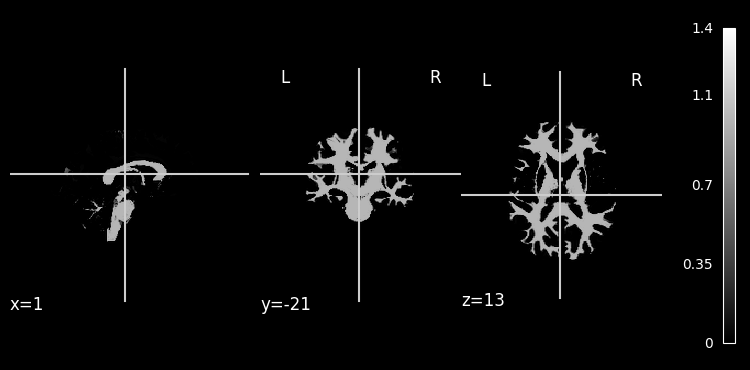

In [107]:
npl.plot_anat(c2_week_img)

In [111]:
c2_week_img.affine[:] = cerebel_week_img.affine

In [112]:
nib.save(c2_week_img, f'c2{subj_id}_{week}_T1_updated_affine.nii.gz')

for regression

In [4]:
import sys
sys.path.append('/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/') # root dir for all fcns

from image_analysis import avg_vol as av

In [5]:
df=p_df[p_df.subj_id == 'CU_2538']

In [17]:
refT1 = 'W0'

In [21]:
ref_img = f'/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/cerebellar_alignment/c2{subj_id}_{refT1}_T1_updated_affine.nii'

In [23]:
betas = avg_vol(subj_id = subj_id, reference_img = ref_img,
                   results_path = '/home/UWO/mporwal2/Documents/GitHub/smarts_cerebellum/cerebellar_alignment',
                   image_suffix = 'native_wm_updated_affine',
                   tissue = 'wm'
                   )

In [8]:
intercept_img = nib.Nifti1Image(intercept, img0.affine)
slope_img = nib.Nifti1Image(slope, img0.affine)

#nib.save(slope_img, f'{subj_id}_T1_slope_native_wm_updated_affine.nii.gz')

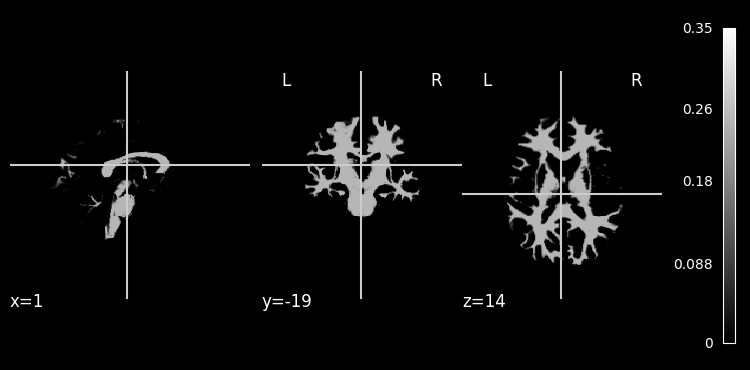

In [9]:
npl.plot_anat(slope_img)

In [ ]:


# CALL FOR WM SEGMENTATION IMAGE IN NATIVE SPACE________

betas = [] # store matrices for all subjects

for subj in df['subj_id'].unique():
    #betas.append(avg_vol(subj, ref_img))
    refT1 = (df.loc[(df['subj_id']==subj), 'RefT1'].iloc[0]).strip()
    ref_img = f'{anat_dir}/{subj}/{refT1}/c2{subj}_{refT1}_T1.nii'

    betas.append(av.avg_vol(subj_id = subj, reference_img=ref_img,
                         results_path = f'{anat_dir}/{subj}/updated_affine_reg/'),
                         image_suffix = '_native_wm_updated_affine',
                         tissue = 'wm'
                         )
    
    # we don't need this weeks loop, the function does it. Really just need to loop through the subject and get their reference img
    # even better if the function can get the reference image itself.
    
    #week = p_df.loc[(p_df['subj_id']==subj), 'week'].iloc[1]
   



TypeError: avg_vol() missing 1 required positional argument: 'image_suffix'

In [118]:
av.avg_vol?

Signature: av.avg_vol(subj_id, reference_img, results_path, image_suffix, tissue=None)
Docstring:
Inputs:
anat dir: participants file OR [(subj, week) and call it inside a loop].
Reference img (inside the Jupyter notebook loop for reading off the info file)
#week_path (path for each week's image), results_path (store results)
results path: directory to store results
image suffix: suffix with which to save the slope and intercept images
    suggested: <image_type>_<space> where 'image_type' is "anat", "wm", "gm", etc; 'space' is native or template (<template_name>)

Everything is done in the reference image. So this function will (...) (resample voxels in other weeks so that they are aligned with the reference, and perform multiple linear regression)

Returns B_hat coefficient matrix (for more flexibility in other possible operations)
File:      ~/Documents/GitHub/smarts_cerebellum/image_analysis/avg_vol.py
Type:      function

One potential issue is a difference in voxel size:
- the reference image has voxel 1.2x1x1, but the later week images have voxel 1x1x1.2 - actually, this is just because of rotation. That's fine.

- but we should check the sizes of the images; I think the coregistered image has a different size (in later weeks) from the not-coregistered image. So would we need to use the not-previously-coregistered image?

- In that case, I think we also need to re-segment all the tissue probabilities.

- no, the tensor sizes of these images shouldn't be and weren't changed. So just do the above.